<a href="https://colab.research.google.com/github/roudhaaln/machine-learning-based-presiction-of-earthquake-magnitude-using-global-seamic-data-/blob/main/EM08DS_Earthquake_Magnitude_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EM08DS Final Project
## Machine Learning-Based Prediction of Earthquake Magnitude Using Global Seismic Data

**Research Question:** How accurately can machine-learning models estimate earthquake magnitude using seismic and geographical features?

This notebook covers data loading, cleaning, EDA, leakage control, feature preparation, Linear Regression, Random Forest, Gradient Boosting, MAE/RMSE/R² evaluation, actual-vs-predicted plots and feature importance.


## 1. Import Libraries

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", None)
RANDOM_STATE = 42


## 2. Load the Dataset
Upload the Kaggle CSV to Colab, then run this cell.


In [ ]:
import zipfile

zip_file_path = '/content/archive.zip'
output_dir = '/content/'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(output_dir)

print(f'Successfully unzipped {zip_file_path} to {output_dir}')

Successfully unzipped /content/archive.zip to /content/


In [ ]:
csv_files = [f for f in os.listdir(".") if f.lower().endswith(".csv")]

if not csv_files:
    raise FileNotFoundError("Upload the earthquake CSV file to Colab, then run again.")

FILE_PATH = csv_files[0]
print("Using file:", FILE_PATH)

df = pd.read_csv(FILE_PATH)
print("Dataset shape:", df.shape)
display(df.head())


Using file: global_earthquakes_2020_2026.csv
Dataset shape: (11808, 21)


,id,time,year,decade,latitude,longitude,depth,mag,magType,place,region,mag_category,nst,gap,dmin,rms,horizontalError,depthError,magError,status,net
0,us70006t13,2020-01-01 00:28:20.289000+00:00,2020,2020,-5.3245,152.5514,40.24,5.1,mb,"112 km SSE of Kokopo, Papua New Guinea",Papua New Guinea,5.0-5.5,NaN,74.0,1.190,0.79,9.4,6.3,0.044,reviewed,us
1,us70006t2a,2020-01-01 03:53:29.023000+00:00,2020,2020,52.6367,159.1614,58.46,5.0,mb,"56 km SE of Petropavlovsk-Kamchatsky, Russia",Russia,NaN,NaN,94.0,0.496,0.66,7.7,4.6,0.026,reviewed,us
2,us70006t3c,2020-01-01 08:31:24.136000+00:00,2020,2020,-17.4280,-172.5044,10.00,5.4,mww,"207 km NE of Neiafu, Tonga",Tonga,5.0-5.5,NaN,40.0,2.947,1.44,8.8,1.8,0.086,reviewed,us
3,us70006t6a,2020-01-01 16:34:59.178000+00:00,2020,2020,-53.0907,9.5001,10.00,5.0,mb,southwest of Africa,southwest of Africa,NaN,NaN,105.0,19.424,0.83,14.0,1.9,0.082,reviewed,us
4,us70006t6h,2020-01-01 16:51:32.285000+00:00,2020,2020,-30.2857,-71.5582,40.88,5.0,mwr,"42 km SSW of Coquimbo, Chile",Chile,NaN,NaN,117.0,0.392,0.72,5.0,2.5,0.038,reviewed,us


## 3. Initial Data Inspection

In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumns:")
print(df.columns.tolist())

display(pd.DataFrame({
    "dtype": df.dtypes,
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean()*100).round(2)
}).sort_values("missing_percent", ascending=False))

print("Duplicate rows:", df.duplicated().sum())
display(df.describe(include="all").T)


Rows: 11808
Columns: 21

Columns:
['id', 'time', 'year', 'decade', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'place', 'region', 'mag_category', 'nst', 'gap', 'dmin', 'rms', 'horizontalError', 'depthError', 'magError', 'status', 'net']


,dtype,missing_count,missing_percent
nst,float64,4272,36.18
mag_category,object,2981,25.25
horizontalError,float64,95,0.80
magError,float64,93,0.79
dmin,float64,90,0.76
gap,float64,86,0.73
rms,float64,31,0.26
latitude,float64,0,0.00
time,object,0,0.00
id,object,0,0.00


Duplicate rows: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,11808,11808,us7000szvv,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time,11808,11808,2026-07-12 13:46:37.185000+00:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,11808.0,NaN,NaN,NaN,2022.848577,1.894017,2020.0,2021.0,2023.0,2025.0,2026.0
decade,11808.0,NaN,NaN,NaN,2020.0,0.0,2020.0,2020.0,2020.0,2020.0,2020.0
latitude,11808.0,NaN,NaN,NaN,-1.107176,33.074095,-69.7739,-23.257025,-4.3305,25.14815,87.386
longitude,11808.0,NaN,NaN,NaN,35.6805,123.549638,-179.9896,-71.9661,95.0412,143.2401,179.9981
depth,11808.0,NaN,NaN,NaN,50.811189,97.330476,0.8,10.0,10.4425,45.559,676.469
mag,11808.0,NaN,NaN,NaN,5.324002,0.395378,5.0,5.0,5.2,5.5,8.8
magType,11808,9,mww,7124,NaN,NaN,NaN,NaN,NaN,NaN,NaN
place,11808,7322,South Sandwich Islands region,706,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Basic Cleaning

In [ ]:
df.columns = (
    df.columns.str.strip().str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

before = len(df)
df = df.drop_duplicates().copy()
print("Duplicates removed:", before - len(df))
print("Cleaned columns:", df.columns.tolist())


Duplicates removed: 0
Cleaned columns: ['id', 'time', 'year', 'decade', 'latitude', 'longitude', 'depth', 'mag', 'magtype', 'place', 'region', 'mag_category', 'nst', 'gap', 'dmin', 'rms', 'horizontalerror', 'deptherror', 'magerror', 'status', 'net']


## 5. Identify the Target Variable

In [ ]:
target = None
for col in ["magnitude", "mag"]:
    if col in df.columns:
        target = col
        break

if target is None:
    raise ValueError("Magnitude column not found. Check df.columns and set target manually.")

df[target] = pd.to_numeric(df[target], errors="coerce")
df = df.dropna(subset=[target]).copy()

print("Target:", target)
display(df[target].describe())


Target: mag


,mag
count,11808.000000
mean,5.324002
std,0.395378
min,5.000000
25%,5.000000
50%,5.200000
75%,5.500000
max,8.800000


## 6. Create Time Features

In [ ]:
time_col = None
for col in ["time", "date", "datetime", "timestamp"]:
    if col in df.columns:
        time_col = col
        break

if time_col:
    df[time_col] = pd.to_datetime(df[time_col], errors="coerce", utc=True)
    df["year"] = df[time_col].dt.year
    df["month"] = df[time_col].dt.month
    df["day_of_week"] = df[time_col].dt.dayofweek
    df["hour"] = df[time_col].dt.hour
    print("Created year, month, day_of_week, hour from", time_col)
else:
    print("No standard time column found.")


Created year, month, day_of_week, hour from time


## 7. Exploratory Data Analysis

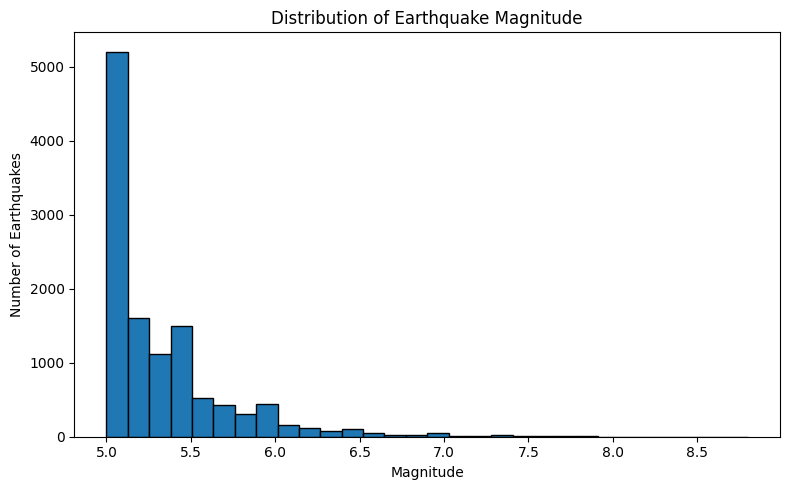

Mean: 5.324
Median: 5.2
Min: 5.0
Max: 8.8


In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df[target].dropna(), bins=30, edgecolor="black")
plt.title("Distribution of Earthquake Magnitude")
plt.xlabel("Magnitude")
plt.ylabel("Number of Earthquakes")
plt.tight_layout()
plt.show()

print("Mean:", round(df[target].mean(),3))
print("Median:", round(df[target].median(),3))
print("Min:", df[target].min())
print("Max:", df[target].max())


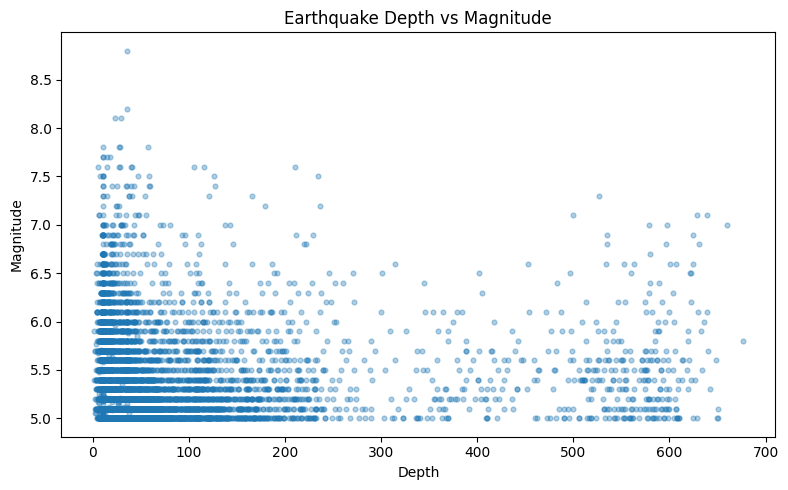

In [ ]:
if "depth" in df.columns:
    depth = pd.to_numeric(df["depth"], errors="coerce")
    plt.figure(figsize=(8,5))
    plt.scatter(depth, df[target], alpha=0.35, s=12)
    plt.title("Earthquake Depth vs Magnitude")
    plt.xlabel("Depth")
    plt.ylabel("Magnitude")
    plt.tight_layout()
    plt.show()


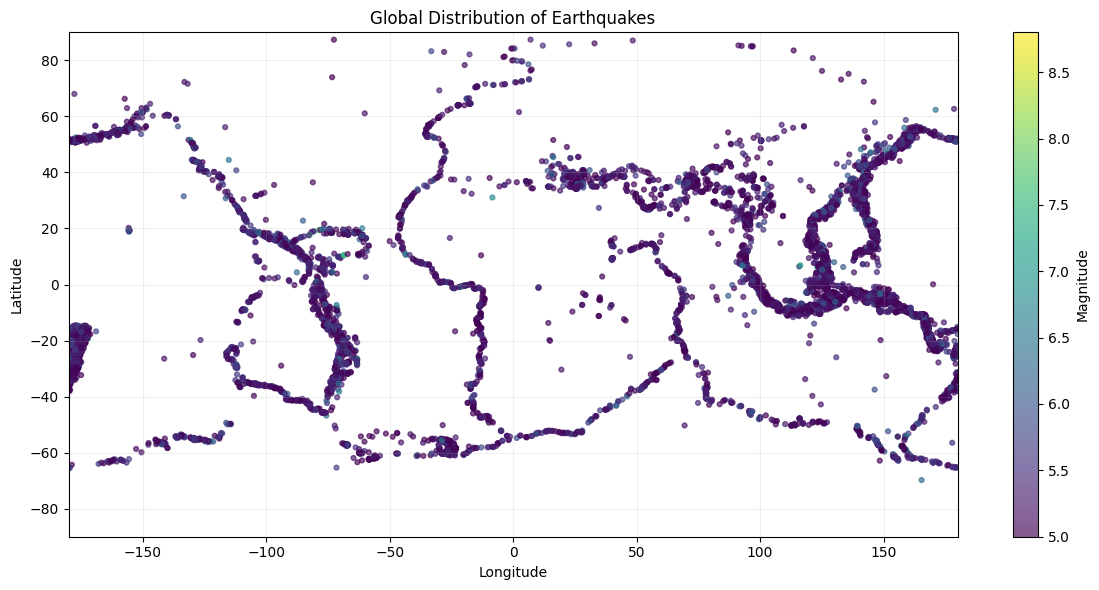

In [ ]:
if {"longitude","latitude"}.issubset(df.columns):
    lon = pd.to_numeric(df["longitude"], errors="coerce")
    lat = pd.to_numeric(df["latitude"], errors="coerce")

    plt.figure(figsize=(12,6))
    sc = plt.scatter(lon, lat, c=df[target], s=12, alpha=0.65)
    plt.colorbar(sc, label="Magnitude")
    plt.title("Global Distribution of Earthquakes")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.xlim(-180,180)
    plt.ylim(-90,90)
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


## 8. Remove Target Leakage and Unhelpful Columns
Magnitude-derived variables must not be used as predictors.


In [ ]:
drop_cols = {target, "id", "url", "detail", "updated", "title"}

if time_col:
    drop_cols.add(time_col)

for col in df.columns:
    compact = col.replace("_","").lower()
    if any(k in compact for k in ["magerror","magcategory","magnitudecategory"]):
        drop_cols.add(col)

constant_cols = [
    c for c in df.columns
    if c != target and df[c].nunique(dropna=False) <= 1
]
drop_cols.update(constant_cols)

drop_cols = [c for c in drop_cols if c in df.columns]

print("Removed from predictors:", sorted(drop_cols))

X = df.drop(columns=drop_cols).copy()
y = df[target].copy()
print("Predictor shape:", X.shape)


Removed from predictors: ['decade', 'id', 'mag', 'mag_category', 'magerror', 'status', 'time']
Predictor shape: (11808, 17)


## 9. Keep Suitable Features

In [ ]:
for col in X.columns:
    if X[col].dtype == "object":
        converted = pd.to_numeric(X[col], errors="coerce")
        original_non_null = X[col].notna().sum()
        converted_non_null = converted.notna().sum()
        if original_non_null and converted_non_null/original_non_null >= 0.90:
            X[col] = converted

categorical_candidates = X.select_dtypes(include=["object","category"]).columns.tolist()

high_cardinality_cols = [
    c for c in categorical_candidates
    if X[c].nunique(dropna=True) > 100
]

print("High-cardinality text removed:", high_cardinality_cols)
X = X.drop(columns=high_cardinality_cols)

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)
print("Final X shape:", X.shape)


High-cardinality text removed: ['place', 'region']
Numerical features: ['year', 'latitude', 'longitude', 'depth', 'nst', 'gap', 'dmin', 'rms', 'horizontalerror', 'deptherror', 'month', 'day_of_week', 'hour']
Categorical features: ['magtype', 'net']
Final X shape: (11808, 15)


## 10. Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))


Training rows: 9446
Testing rows: 2362


## 11. Preprocessing

In [ ]:
num_linear = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

num_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

linear_preprocessor = ColumnTransformer([
    ("num", num_linear, numeric_features),
    ("cat", cat_pipe, categorical_features)
])

tree_preprocessor = ColumnTransformer([
    ("num", num_tree, numeric_features),
    ("cat", cat_pipe, categorical_features)
])


## 12. Train the Models

In [ ]:
models = {
    "Linear Regression": Pipeline([
        ("preprocessor", linear_preprocessor),
        ("model", LinearRegression())
    ]),
    "Random Forest": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),
    "Gradient Boosting": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("model", GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=RANDOM_STATE
        ))
    ])
}

for name, model in models.items():
    print("Training:", name)
    model.fit(X_train, y_train)

print("Done.")


Training: Linear Regression
Training: Random Forest
Training: Gradient Boosting
Done.


## 13. Evaluate Models

In [ ]:
results = []
predictions = {}

for name, model in models.items():
    pred = model.predict(X_test)
    predictions[name] = pred

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2": r2_score(y_test, pred)
    })

results_df = pd.DataFrame(results).sort_values("MAE").reset_index(drop=True)
display(results_df.round(4))

best_model_name = results_df.iloc[0]["Model"]
print("Best model by MAE:", best_model_name)


,Model,MAE,RMSE,R2
0,Random Forest,0.1930,0.2930,0.4634
1,Gradient Boosting,0.1977,0.2982,0.4439
2,Linear Regression,0.2360,0.3427,0.2656


Best model by MAE: Random Forest


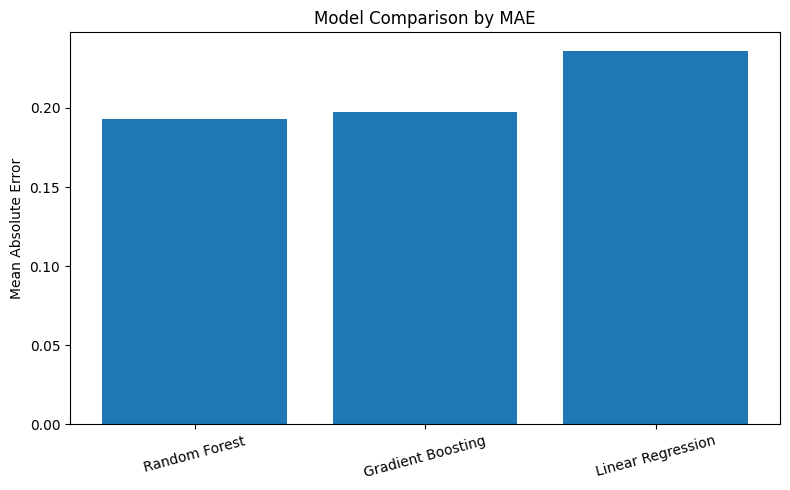

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["MAE"])
plt.title("Model Comparison by MAE")
plt.ylabel("Mean Absolute Error")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## 14. Actual vs Predicted

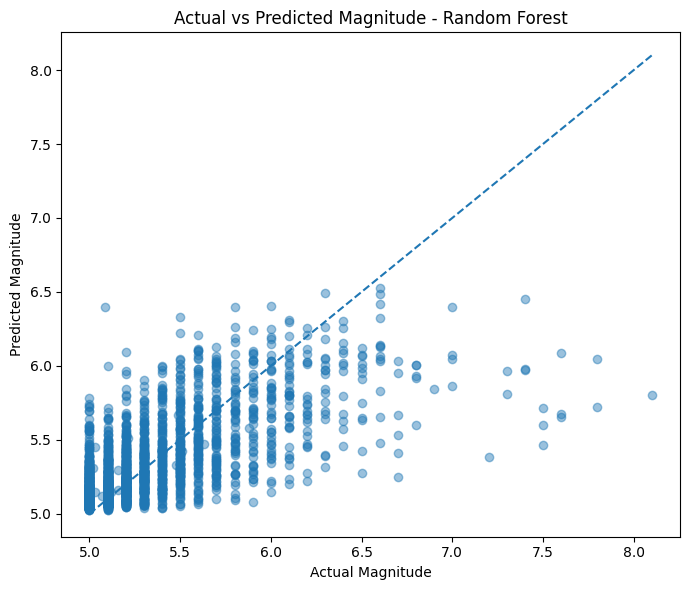

In [ ]:
best_predictions = predictions[best_model_name]

plt.figure(figsize=(7,6))
plt.scatter(y_test, best_predictions, alpha=0.45)

low = min(y_test.min(), best_predictions.min())
high = max(y_test.max(), best_predictions.max())
plt.plot([low, high], [low, high], linestyle="--")

plt.title(f"Actual vs Predicted Magnitude - {best_model_name}")
plt.xlabel("Actual Magnitude")
plt.ylabel("Predicted Magnitude")
plt.tight_layout()
plt.show()


## 15. Residual Plot

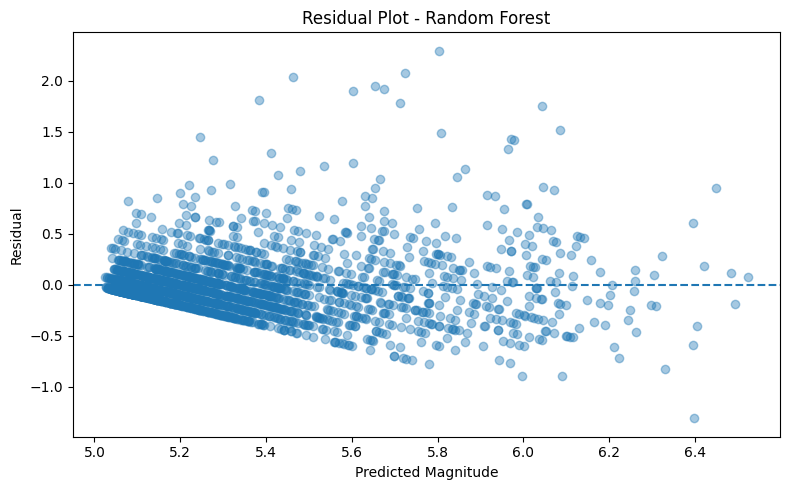

In [ ]:
residuals = y_test.to_numpy() - best_predictions

plt.figure(figsize=(8,5))
plt.scatter(best_predictions, residuals, alpha=0.4)
plt.axhline(0, linestyle="--")
plt.title(f"Residual Plot - {best_model_name}")
plt.xlabel("Predicted Magnitude")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()


## 16. Feature Importance

,Feature,Importance
10,deptherror,0.057074
4,magtype,0.052855
3,depth,0.042538
6,gap,0.030245
1,latitude,0.014388
2,longitude,0.008605
5,nst,0.007144
7,dmin,0.004547
9,horizontalerror,0.003459
8,rms,0.002261


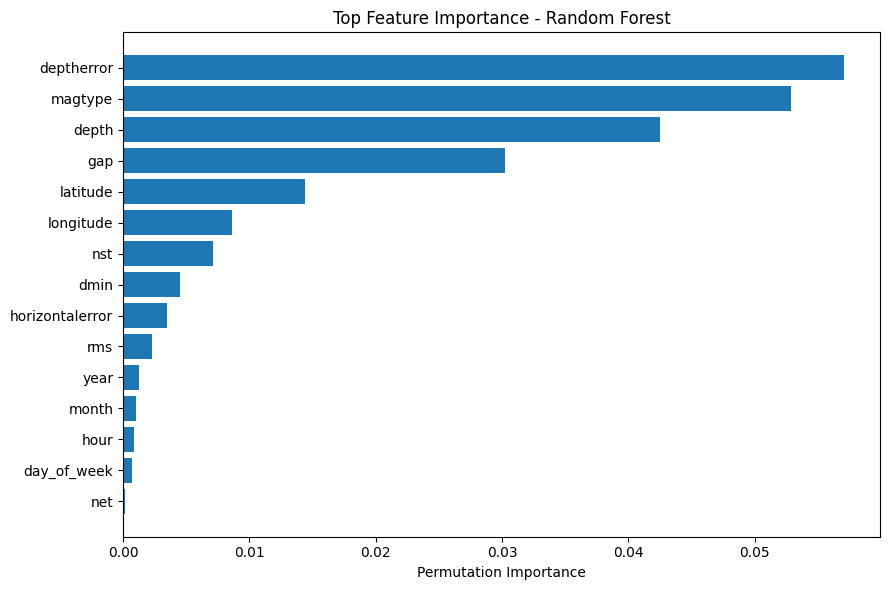

In [ ]:
best_model = models[best_model_name]

perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring="neg_mean_absolute_error"
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm.importances_mean
}).sort_values("Importance", ascending=False)

display(importance_df.head(15))

top_imp = importance_df.head(15).sort_values("Importance")

plt.figure(figsize=(9,6))
plt.barh(top_imp["Feature"], top_imp["Importance"])
plt.title(f"Top Feature Importance - {best_model_name}")
plt.xlabel("Permutation Importance")
plt.tight_layout()
plt.show()


## 17. Final Results for the Report

In [ ]:
print("="*60)
print("FINAL MODEL RESULTS")
print("="*60)
display(results_df.round(4))

best_row = results_df.iloc[0]

print("Best model:", best_model_name)
print("MAE :", round(best_row["MAE"],4))
print("RMSE:", round(best_row["RMSE"],4))
print("R²  :", round(best_row["R2"],4))

print("\nTop 10 important features:")
display(importance_df.head(10))


FINAL MODEL RESULTS


,Model,MAE,RMSE,R2
0,Random Forest,0.1930,0.2930,0.4634
1,Gradient Boosting,0.1977,0.2982,0.4439
2,Linear Regression,0.2360,0.3427,0.2656


Best model: Random Forest
MAE : 0.193
RMSE: 0.293
R²  : 0.4634

Top 10 important features:


,Feature,Importance
10,deptherror,0.057074
4,magtype,0.052855
3,depth,0.042538
6,gap,0.030245
1,latitude,0.014388
2,longitude,0.008605
5,nst,0.007144
7,dmin,0.004547
9,horizontalerror,0.003459
8,rms,0.002261


## 18. Save Results

In [ ]:
results_df.to_csv("model_results.csv", index=False)
importance_df.to_csv("feature_importance.csv", index=False)

pd.DataFrame({
    "Actual_Magnitude": y_test.reset_index(drop=True),
    "Predicted_Magnitude": best_predictions
}).to_csv("best_model_predictions.csv", index=False)

print("Saved model_results.csv, feature_importance.csv and best_model_predictions.csv")


Saved model_results.csv, feature_importance.csv and best_model_predictions.csv
